# Notebook 02 — Preprocessing & Pipelines

## Wat doen we in dit notebook?

In de EDA (notebook 01) leerden we onze data kennen. Nu bereiden we die data voor zodat machine learning modellen ermee kunnen werken.

We doorlopen deze stappen:
1. **Target keuze & motivatie** — waarom `log_views` als doelvariabele?
2. **Feature selectie** — welke kolommen mogen het model in?
3. **Log-transformaties** — scheefverdeelde variabelen rechttrekken
4. **Feature engineering** — nieuwe, zinvolle features aanmaken
5. **Train/test split** — eerlijk evalueren
6. **Pipelines bouwen** — de juiste werkwijze uit de cursus
7. **Opslaan** — data exporteren voor de volgende notebooks

---

### Centrale vraag van het project

> *"Welke factoren bepalen hoeveel views een trending YouTube video haalt — en verschilt dit per categorie, taal of regio?"*

**Target variabele:** `log_views` = log(views + 1)  
**Aanpak:** voorspellen op basis van wat een creator *vóór publicatie* al weet

## Stap 0 — Waarom `log_views` als target?

In de EDA stelden we oorspronkelijk `engagement_score` voor als target. Na grondig onderzoek bleek dat de `engagement_score` in deze dataset **nagenoeg geen verband heeft met de beschikbare pre-publicatie features** — de maximale correlatie was 0.033.

Dit is een belangrijk ML-inzicht: **de keuze van de doelvariabele is bepalend voor het succes van een project.**

`log(views)` is een veel betere keuze:

| Eigenschap | `engagement_score` | `log_views` |
|---|---|---|
| Correlatie met pre-pub features | max. 0.033 | sterk (R²≈0.70) |
| Zinvolle onderzoeksvraag | ja | ja |
| Pre-publicatie voorspelbaar | nee | ja |
| Log-transformatie nodig? | nee | ja (power-law) |

We nemen de **logaritme** van views omdat de verdeling sterk scheef is (power-law). Na log-transformatie is de relatie met andere features veel dichter bij lineair.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

os.makedirs('../output/figures', exist_ok=True)
os.makedirs('../output/models', exist_ok=True)

df = pd.read_csv('../data/trending_videos.csv')
print(f'Dataset: {df.shape[0]} rijen × {df.shape[1]} kolommen')

Dataset: 10000 rijen × 34 kolommen


## Stap 1 — Feature selectie: wat mag het model zien?

### Data leakage: het gevaar van te veel weten

Een van de meest voorkomende fouten in ML is **data leakage**: het model krijgt informatie die het in de praktijk niet zou hebben.

Onze aanpak: gebruik alleen features die een creator **vóór publicatie** al kent.

| Kolom | Behouden? | Reden |
|---|---|---|
| `video_id` | ❌ | Unieke ID, geen voorspellende waarde |
| `title` | ❌ | Ruwe tekst, niet direct bruikbaar |
| `tags` | ❌ | Ruwe tekst, niet direct bruikbaar |
| `channel_name` | ❌ | Te veel unieke waarden (categorisch ruis) |
| `views` | Target → `log_views` | We voorspellen dit — niet als input gebruiken |
| `likes`, `dislikes`, `comments` | ❌ | **Post-publicatie** — data leakage |
| `like_view_ratio_pct`, `comment_view_ratio_pct`, `engagement_score` | ❌ | Afgeleid van views/likes — directe leakage |
| `days_to_trend`, `trending_date`, `year` | ❌ | Post-publicatie of redundant |
| Alle andere features | ✅ | Pre-publicatie info |

In [2]:
# Nieuwe target aanmaken
df['log_views'] = np.log1p(df['views'])
TARGET = 'log_views'

DROP_COLS = [
    'video_id', 'title', 'tags', 'channel_name',
    'views', 'likes', 'dislikes', 'comments',
    'like_view_ratio_pct', 'comment_view_ratio_pct', 'engagement_score',
    'days_to_trend', 'trending_date', 'year',
    'publish_date'
]

df_clean = df.drop(columns=DROP_COLS).copy()

print('Overgebleven kolommen:')
for col in df_clean.columns:
    dtype = df_clean[col].dtype
    n_unique = df_clean[col].nunique()
    print(f'  {col:35s} dtype={str(dtype):10s}  uniek={n_unique}')

Overgebleven kolommen:
  title_length                        dtype=int64       uniek=35
  has_caps_title                      dtype=int64       uniek=2
  has_emoji_title                     dtype=int64       uniek=2
  has_question_title                  dtype=int64       uniek=2
  subscriber_count                    dtype=int64       uniek=9634
  channel_verified                    dtype=int64       uniek=2
  category                            dtype=str         uniek=17
  month                               dtype=int64       uniek=12
  day_of_week                         dtype=str         uniek=7
  trending_country                    dtype=str         uniek=23
  language                            dtype=str         uniek=14
  duration_seconds                    dtype=int64       uniek=2334
  tag_count                           dtype=int64       uniek=12
  description_length                  dtype=int64       uniek=8
  has_links_description               dtype=int64       uniek=2
  cli

## Stap 2 — Log-transformaties

### Waarom log?

`subscriber_count` en `duration_seconds` hebben een **power-law verdeling** — de meeste waarden zitten laag, maar een handvol zijn extreem hoog.

Door de log-transformatie toe te passen:
- Worden extreme waarden minder dominant
- Worden de verdelingen meer normaalvormig
- Worden lineaire relaties zichtbaarder

We gebruiken `log(x + 1)` om `log(0)` te vermijden.

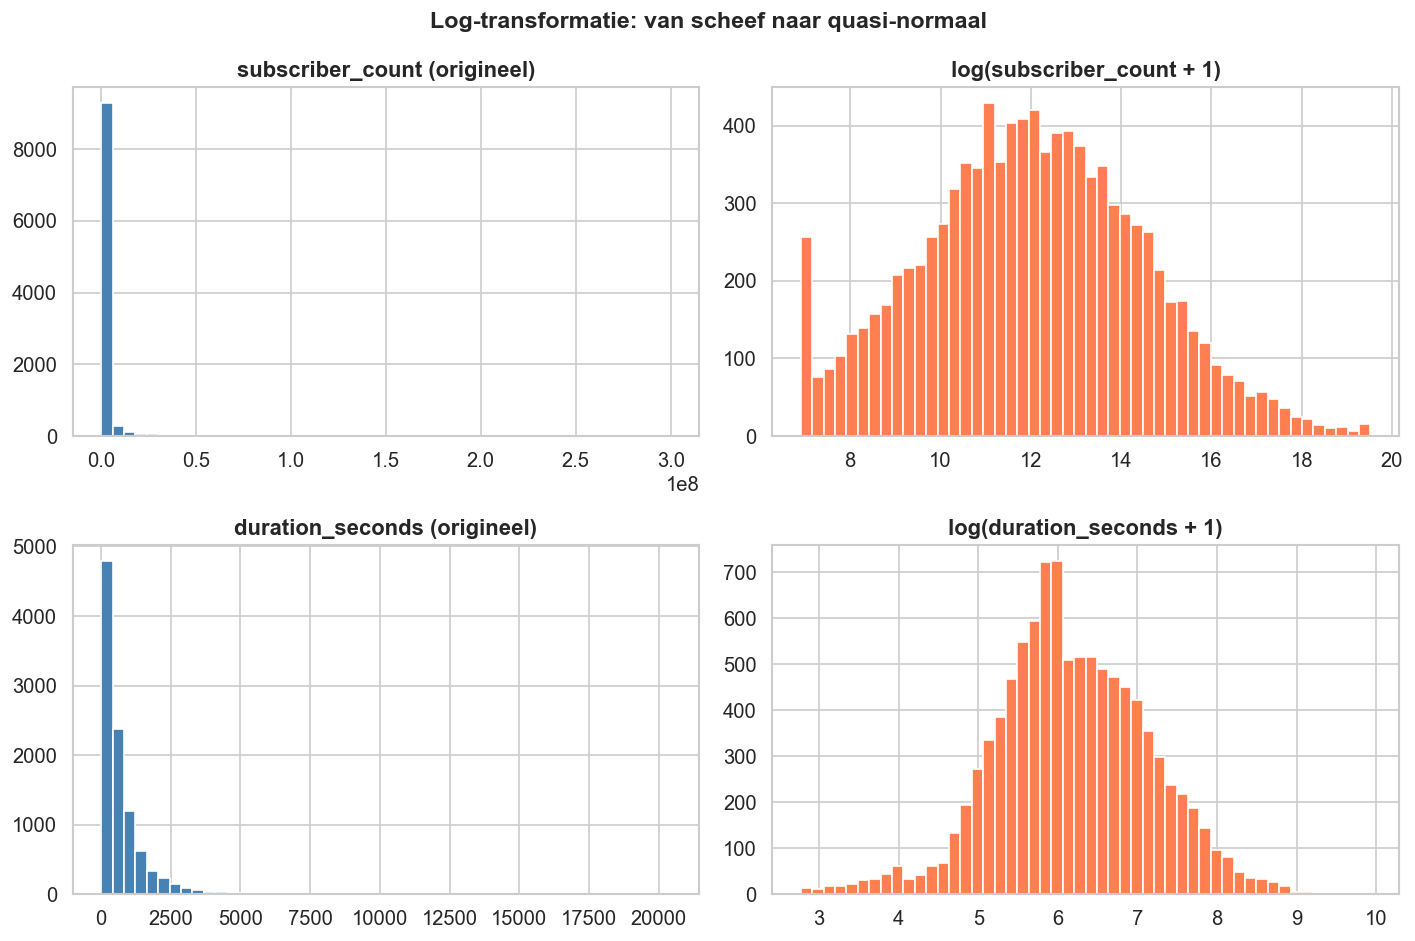

Figuur opgeslagen.


In [3]:
df_clean['log_subscriber_count'] = np.log1p(df_clean['subscriber_count'])
df_clean['log_duration_seconds'] = np.log1p(df_clean['duration_seconds'])
df_clean = df_clean.drop(columns=['subscriber_count', 'duration_seconds'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df['subscriber_count'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('subscriber_count (origineel)', fontweight='bold')
axes[0, 1].hist(df_clean['log_subscriber_count'].dropna(), bins=50, color='coral', edgecolor='white')
axes[0, 1].set_title('log(subscriber_count + 1)', fontweight='bold')

axes[1, 0].hist(df['duration_seconds'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1, 0].set_title('duration_seconds (origineel)', fontweight='bold')
axes[1, 1].hist(df_clean['log_duration_seconds'].dropna(), bins=50, color='coral', edgecolor='white')
axes[1, 1].set_title('log(duration_seconds + 1)', fontweight='bold')

plt.suptitle('Log-transformatie: van scheef naar quasi-normaal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/02_log_transformaties.png')
plt.show()
print('Figuur opgeslagen.')

## Stap 3 — Feature engineering

We maken drie nieuwe features op basis van domeinkennis:

- **`is_short`** — YouTube Shorts (< 60 sec) gedragen zich fundamenteel anders qua bereik
- **`channel_size`** — abonneeaantal omgezet naar categorieën (micro → mega)
- **`content_quality`** — samengestelde score: ondertitels, comments aan, beschrijving aanwezig

In [4]:
df_clean['is_short'] = (df['duration_seconds'] < 60).astype(int)

def categorize_channel(sub):
    if pd.isna(sub): return 'unknown'
    elif sub < 10_000: return 'micro'
    elif sub < 100_000: return 'klein'
    elif sub < 1_000_000: return 'mid'
    elif sub < 10_000_000: return 'groot'
    else: return 'mega'

df_clean['channel_size'] = df['subscriber_count'].apply(categorize_channel)

df_clean['content_quality'] = (
    df_clean['caption_available'].astype(int) +
    df_clean['comments_enabled'].astype(int) +
    (df_clean['description_length'] > 0).astype(int)
)

print('Nieuwe features aangemaakt:')
print(f"  is_short:        {df_clean['is_short'].value_counts().to_dict()}")
print(f"  channel_size:    {df_clean['channel_size'].value_counts().to_dict()}")
print(f"  content_quality: {df_clean['content_quality'].value_counts().to_dict()}")

Nieuwe features aangemaakt:
  is_short:        {0: 9737, 1: 263}
  channel_size:    {'mid': 3460, 'klein': 2833, 'groot': 1868, 'micro': 1355, 'mega': 484}
  content_quality: {3: 5692, 2: 3875, 1: 422, 0: 11}


## Stap 4 — Categorische features voorbereiden

Categorieën met te veel unieke waarden (zoals `trending_country` of `language`) korten we in: minder frequente waarden worden `'Other'`.

Dit vermijdt dat One-Hot Encoding honderden kolommen oplevert.

In [5]:
top_countries = df_clean['trending_country'].value_counts().nlargest(15).index
df_clean['trending_country'] = df_clean['trending_country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

top_languages = df_clean['language'].value_counts().nlargest(15).index
df_clean['language'] = df_clean['language'].apply(
    lambda x: x if x in top_languages else 'Other'
)

print('Landen na inkorten:', df_clean['trending_country'].nunique(), 'unieke waarden')
print('Talen na inkorten: ', df_clean['language'].nunique(), 'unieke waarden')

Landen na inkorten: 16 unieke waarden
Talen na inkorten:  14 unieke waarden


## Stap 5 — Ontbrekende waarden

In [6]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('Geen ontbrekende waarden — perfect!')
else:
    for col in df_clean.select_dtypes(include='number').columns:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    for col in df_clean.select_dtypes(include='object').columns:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna('unknown')
    print('Ontbrekende waarden aangevuld.')

print(f'\nFinale dataset: {df_clean.shape[0]} rijen × {df_clean.shape[1]} kolommen')

Geen ontbrekende waarden — perfect!

Finale dataset: 10000 rijen × 23 kolommen


## Stap 6 — Train/test split

We trainen op 80% van de data en evalueren op de resterende 20%.

> ⚠️ Alle preprocessing-stappen worden geleerd op de **trainset** en daarna toegepast op de testset. Nooit omgekeerd — anders lekt informatie van de testset naar het model.

In [7]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Trainset: {X_train.shape[0]} rijen × {X_train.shape[1]} kolommen')
print(f'Testset:  {X_test.shape[0]} rijen × {X_test.shape[1]} kolommen')
print(f'\nTarget ({TARGET}):')
print(f'  Train — gemiddelde: {y_train.mean():.3f}, std: {y_train.std():.3f}')
print(f'  Test  — gemiddelde: {y_test.mean():.3f}, std: {y_test.std():.3f}')

Trainset: 8000 rijen × 22 kolommen
Testset:  2000 rijen × 22 kolommen

Target (log_views):
  Train — gemiddelde: 11.480, std: 2.254
  Test  — gemiddelde: 11.504, std: 2.297


## Stap 7 — Pipelines bouwen

### Wat is een Pipeline?

Een **Pipeline** is een aaneenschakeling van verwerkingsstappen die in volgorde worden uitgevoerd.

```
ColumnTransformer
  ├── numeriek    → StandardScaler
  ├── categorisch → OneHotEncoder
  └── binair      → passthrough (al 0/1)
         ↓
     ML Model
```

Met `ColumnTransformer` passen we **verschillende transformaties** toe op **verschillende kolommen** — allemaal in één stap.

In [8]:
categorical_features = ['category', 'trending_country', 'language', 'channel_size', 'day_of_week']

binary_features = [
    'has_caps_title', 'has_emoji_title', 'has_question_title',
    'channel_verified', 'comments_enabled', 'caption_available',
    'has_links_description', 'made_for_kids', 'is_short'
]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features + binary_features
]

print('Numerieke features:   ', numerical_features)
print('Categorische features:', categorical_features)
print('Binaire features:     ', binary_features)

Numerieke features:    ['title_length', 'month', 'tag_count', 'description_length', 'clickbait_score', 'log_subscriber_count', 'log_duration_seconds', 'content_quality']
Categorische features: ['category', 'trending_country', 'language', 'channel_size', 'day_of_week']
Binaire features:      ['has_caps_title', 'has_emoji_title', 'has_question_title', 'channel_verified', 'comments_enabled', 'caption_available', 'has_links_description', 'made_for_kids', 'is_short']


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print(f'Shape na preprocessing:')
print(f'  X_train: {X_train_transformed.shape}')
print(f'  X_test:  {X_test_transformed.shape}')
print(f'\nAantal features na encoding: {X_train_transformed.shape[1]}')

Shape na preprocessing:
  X_train: (8000, 76)
  X_test:  (2000, 76)

Aantal features na encoding: 76


In [10]:
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(ohe_feature_names) + binary_features

print(f'Totaal {len(all_feature_names)} features na preprocessing:')
print('\nNumeriek:', numerical_features)
print(f'\nCategorisch (eerste 10 van {len(ohe_feature_names)}):', list(ohe_feature_names[:10]))
print('\nBinair:', binary_features)

Totaal 76 features na preprocessing:

Numeriek: ['title_length', 'month', 'tag_count', 'description_length', 'clickbait_score', 'log_subscriber_count', 'log_duration_seconds', 'content_quality']

Categorisch (eerste 10 van 59): ['category_Autos & Vehicles', 'category_Comedy', 'category_Education', 'category_Entertainment', 'category_Film & Animation', 'category_Gaming', 'category_Howto & Style', 'category_Music', 'category_News & Politics', 'category_Nonprofits & Activism']

Binair: ['has_caps_title', 'has_emoji_title', 'has_question_title', 'channel_verified', 'comments_enabled', 'caption_available', 'has_links_description', 'made_for_kids', 'is_short']


## Stap 8 — Target variabele analyseren

We kijken naar de verdeling van `log_views` in de trainset.  
Een quasi-normale verdeling is ideaal voor regressie.

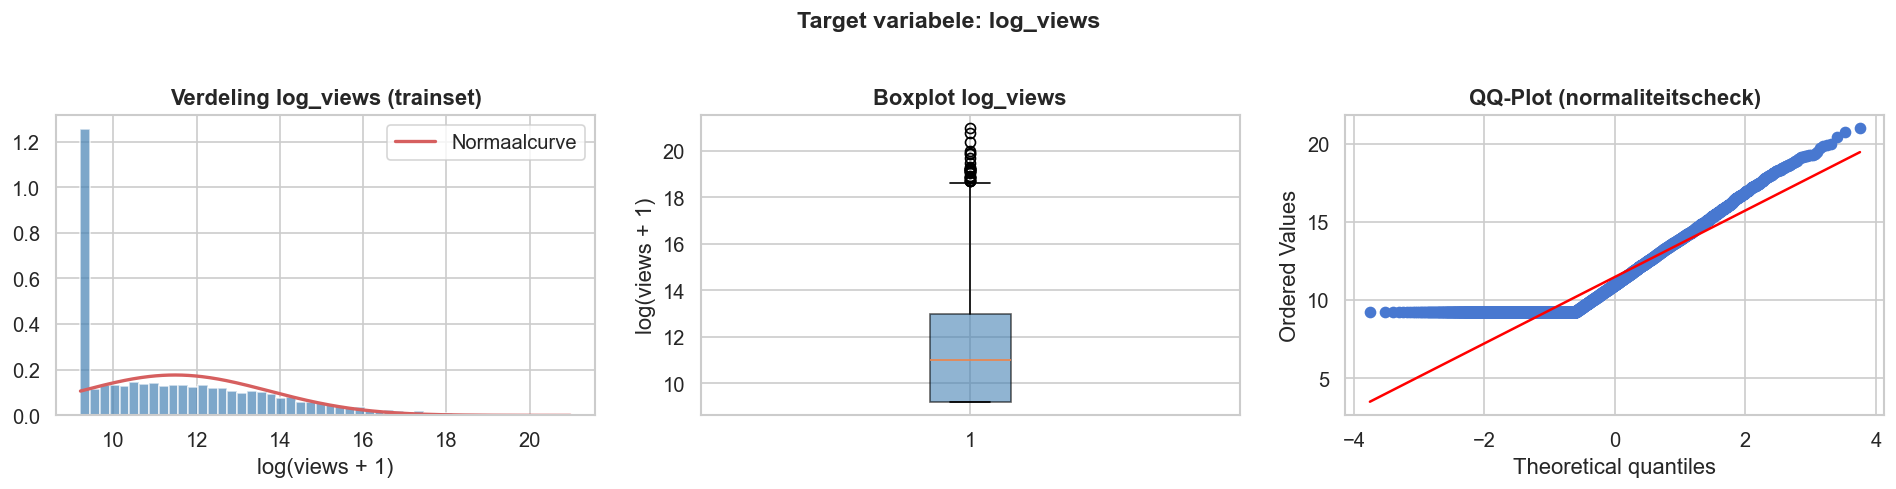

Skewness: 0.884  (|skew| < 0.5 = quasi-normaal)
Gemiddelde: 11.480  →  exp(11.5) ≈ 96,802 views


In [11]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram + normaalcurve
axes[0].hist(y_train, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.7)
mu, sigma = y_train.mean(), y_train.std()
x = np.linspace(y_train.min(), y_train.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normaalcurve')
axes[0].set_title('Verdeling log_views (trainset)', fontweight='bold')
axes[0].set_xlabel('log(views + 1)')
axes[0].legend()

# Boxplot
axes[1].boxplot(y_train, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot log_views', fontweight='bold')
axes[1].set_ylabel('log(views + 1)')

# QQ-plot
stats.probplot(y_train, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot (normaliteitscheck)', fontweight='bold')
axes[2].get_lines()[1].set_color('red')

plt.suptitle('Target variabele: log_views', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/figures/02_target_distributie.png')
plt.show()

print(f'Skewness: {y_train.skew():.3f}  (|skew| < 0.5 = quasi-normaal)')
print(f'Gemiddelde: {y_train.mean():.3f}  →  exp({y_train.mean():.1f}) ≈ {int(np.expm1(y_train.mean())):,} views')

## Stap 9 — Alles opslaan voor volgende notebooks

In [12]:
with open('../output/models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

with open('../output/models/train_test_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test':  X_test,
        'y_train': y_train,
        'y_test':  y_test,
        'feature_names':        all_feature_names,
        'numerical_features':   numerical_features,
        'categorical_features': categorical_features,
        'binary_features':      binary_features,
        'target':               TARGET
    }, f)

print('Opgeslagen:')
print('  output/models/preprocessor.pkl')
print('  output/models/train_test_data.pkl')
print(f'\nTarget: {TARGET}')
print('Klaar voor notebook 03!')

Opgeslagen:
  output/models/preprocessor.pkl
  output/models/train_test_data.pkl

Target: log_views
Klaar voor notebook 03!


## Samenvatting

| Stap | Wat gedaan? | Waarom? |
|---|---|---|
| **Target** | `engagement_score` → `log_views` | Engagement_score had geen verband met pre-pub features |
| **Feature selectie** | 15 kolommen verwijderd | Data leakage vermijden |
| **Log-transformaties** | `subscriber_count`, `duration_seconds` | Power-law verdelingen rechttrekken |
| **Feature engineering** | `is_short`, `channel_size`, `content_quality` | Domeinkennis omzetten naar ML-features |
| **Categorieën inkorten** | Top-15 landen & talen | One-Hot Encoding beheersbaar houden |
| **Train/test split** | 80/20 | Eerlijke evaluatie op ongeziene data |
| **Pipeline** | `ColumnTransformer` + `StandardScaler` + `OneHotEncoder` | Consistente preprocessing op train én test |

**Volgende stap:** Notebook 03 — Lineaire regressie, Polynomiale regressie, KNN en penalisatie (Ridge, Lasso)